# Навчання з підкріпленням: Policy Iteration для FrozenLake

**Тема 9.** Застосуємо **марковський процес ухвалення рішень (MDP)** та алгоритм **ітерації за політиками (Policy Iteration)** для пошуку оптимальної політики в середовищі **FrozenLake-v1** з OpenAI Gym.

**Задача.** Агент має пройти замерзлим озером $4\times4$ від старту `S` до цілі `G`, не потрапивши в ополонки `H`. Лід **слизький** (`is_slippery=True`), тож дія веде у бажаному напрямку лише з імовірністю $1/3$ — це і робить задачу стохастичним MDP, у якому переходи між станами утворюють **ланцюг Маркова**, керований політикою.

**Елементи MDP:** стани $S$ (16 клітинок), дії $A$ (↑↓←→), функція переходів $P(s'\mid s,a)$, винагорода $R$ (1 за досягнення цілі, інакше 0), коефіцієнт знижки/стискання $\gamma$.

## Імпорти та створення середовища

In [1]:
# У сучасних версіях OpenAI Gym підтримується як gymnasium.
# Якщо у Colab не встановлено — розкоментуйте рядок нижче:
# !pip install gymnasium
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

np.random.seed(42)
%matplotlib inline

## 1. Завантаження середовища `FrozenLake-v1`

Створюємо середовище та розглядаємо його модель переходів `env.P` (у новому API — `env.unwrapped.P`). Це словник $P[s][a] = [(p, s', r, done), \dots]$ — саме він задає марковську динаміку.

In [2]:
env = gym.make('FrozenLake-v1', is_slippery=True)
env.reset(seed=42)

n_states = env.observation_space.n
n_actions = env.action_space.n
print('Кількість станів:', n_states)
print('Кількість дій:  ', n_actions, '(0=Left, 1=Down, 2=Right, 3=Up)')

# Карта озера
desc = env.unwrapped.desc.astype(str)
print('\nКарта озера:')
for row in desc:
    print(' '.join(row))

print('\nПриклад переходів P[14][2] (стан 14, дія Right):')
for p, s_next, r, done in env.unwrapped.P[14][2]:
    print(f'  ймовірність={p:.3f} -> стан {s_next}, винагорода={r}, термінальний={done}')

Кількість станів: 16
Кількість дій:   4 (0=Left, 1=Down, 2=Right, 3=Up)

Карта озера:
S F F F
F H F H
F F F H
H F F G

Приклад переходів P[14][2] (стан 14, дія Right):
  ймовірність=0.333 -> стан 14, винагорода=0, термінальний=False
  ймовірність=0.333 -> стан 15, винагорода=1, термінальний=True
  ймовірність=0.333 -> стан 10, винагорода=0, термінальний=False


## 2. Функція `compute_value_function()`

Обчислює **функцію цінності** $V^\pi(s)$ для заданої політики $\pi$ методом ітеративного розв'язання рівнянь Беллмана:
$$V^\pi(s) = \sum_{s'} P(s'\mid s,\pi(s))\,\big[R(s,\pi(s),s') + \gamma V^\pi(s')\big].$$
Ітеруємо, доки зміна цінності не стане меншою за поріг збіжності.

In [3]:
def compute_value_function(policy, env, gamma=1.0, threshold=1e-10):
    """Оцінка політики: обчислення V^pi для всіх станів."""
    n = env.observation_space.n
    value_table = np.zeros(n)
    while True:
        updated_value = np.copy(value_table)
        for state in range(n):
            action = policy[state]
            # рівняння Беллмана для фіксованої дії політики
            value_table[state] = sum(
                trans_prob * (reward + gamma * updated_value[next_state])
                for trans_prob, next_state, reward, done in env.unwrapped.P[state][action]
            )
        # перевірка збіжності
        if np.sum(np.abs(updated_value - value_table)) <= threshold:
            break
    return value_table

### Допоміжна функція: `extract_policy()`

За відомою функцією цінності будує **жадібну** політику — у кожному стані обирає дію, що максимізує очікувану цінність (Q-функцію):
$$\pi(s) = \arg\max_a \sum_{s'} P(s'\mid s,a)\,[R + \gamma V(s')].$$

In [4]:
def extract_policy(value_table, env, gamma=1.0):
    """Жадібна політика відносно функції цінності."""
    n = env.observation_space.n
    n_actions = env.action_space.n
    policy = np.zeros(n, dtype=int)
    for state in range(n):
        q_values = np.zeros(n_actions)
        for action in range(n_actions):
            q_values[action] = sum(
                trans_prob * (reward + gamma * value_table[next_state])
                for trans_prob, next_state, reward, done in env.unwrapped.P[state][action]
            )
        policy[state] = np.argmax(q_values)
    return policy

## 3. Функція `policy_iteration()`

Алгоритм чергує два кроки, доки політика не перестане змінюватися:
1. **Оцінка політики** — `compute_value_function()`;
2. **Покращення політики** — `extract_policy()`.

Це і є **ітерація за політиками**; вона гарантовано збігається до оптимальної політики.

In [5]:
def policy_iteration(env, gamma=1.0, n_iterations=200000):
    """Пошук оптимальної політики методом ітерації за політиками."""
    n = env.observation_space.n
    policy = np.zeros(n, dtype=int)  # початкова політика (усюди дія 0)
    for i in range(n_iterations):
        # 1) оцінка поточної політики
        value_function = compute_value_function(policy, env, gamma)
        # 2) покращення політики
        new_policy = extract_policy(value_function, env, gamma)
        # 3) якщо політика стабілізувалась — завершуємо
        if np.array_equal(policy, new_policy):
            print(f'Policy Iteration збіглася на ітерації {i + 1}')
            break
        policy = new_policy
    return policy, value_function

### Пошук оптимальної політики

Запускаємо для $\gamma = 0.99$.

In [6]:
optimal_policy, optimal_value = policy_iteration(env, gamma=0.99)

print('\nОптимальна політика (номери дій):')
print(optimal_policy.reshape(4, 4))
print('\nФункція цінності V*(s):')
print(np.round(optimal_value.reshape(4, 4), 3))

Policy Iteration збіглася на ітерації 7

Оптимальна політика (номери дій):
[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]

Функція цінності V*(s):
[[0.542 0.499 0.471 0.457]
 [0.558 0.    0.358 0.   ]
 [0.592 0.643 0.615 0.   ]
 [0.    0.742 0.863 0.   ]]


### Візуалізація політики стрілками

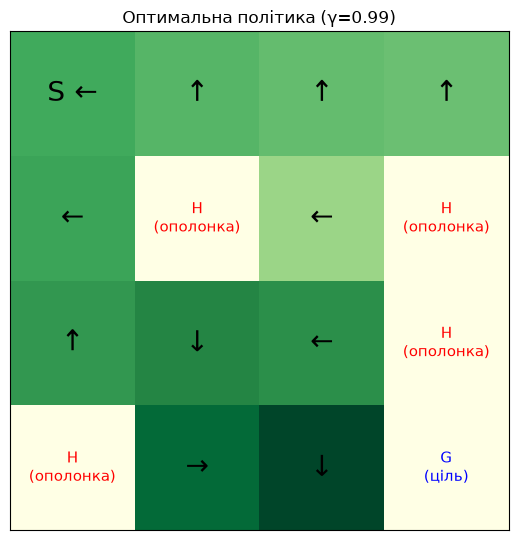

In [7]:
action_arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}

def plot_policy(policy, value, desc, title='Оптимальна політика'):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    grid = desc  # 4x4 масив символів
    ax.imshow(value.reshape(4, 4), cmap='YlGn')
    for i in range(4):
        for j in range(4):
            cell = grid[i, j]
            s = i * 4 + j
            if cell == 'H':
                ax.text(j, i, 'H\n(ополонка)', ha='center', va='center', color='red', fontsize=11)
            elif cell == 'G':
                ax.text(j, i, 'G\n(ціль)', ha='center', va='center', color='blue', fontsize=11)
            else:
                label = action_arrows[policy[s]]
                if cell == 'S':
                    label = 'S ' + label
                ax.text(j, i, label, ha='center', va='center', fontsize=20)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_policy(optimal_policy, optimal_value, desc, 'Оптимальна політика (γ=0.99)')

## 4. Візуалізація роботи політики: `show_render()`

Функція проганяє один епізод у середовищі, на кожному кроці відображаючи стан агента на полі. Використовуємо текстовий рендеринг (`render_mode='ansi'`), який стабільно працює в будь-якому середовищі, зокрема в Colab.

In [8]:
def show_render(policy, gamma_title='', seed=0, max_steps=100, pause=0.4):
    """Візуалізація епізоду: агент рухається за політикою від S до G."""
    render_env = gym.make('FrozenLake-v1', is_slippery=True, render_mode='ansi')
    state, _ = render_env.reset(seed=seed)
    total_reward = 0
    for step in range(max_steps):
        clear_output(wait=True)
        print(f'Крок {step}  {gamma_title}')
        print(render_env.render())
        action = int(policy[state])
        state, reward, terminated, truncated, _ = render_env.step(action)
        total_reward += reward
        time.sleep(pause)
        if terminated or truncated:
            clear_output(wait=True)
            print(f'Крок {step + 1}  {gamma_title}')
            print(render_env.render())
            result = 'ДОСЯГНУТО ЦІЛІ! 🏁' if reward > 0 else 'Впав в ополонку 🕳'
            print(f'Епізод завершено. Результат: {result}  (винагорода={total_reward})')
            break
    render_env.close()

show_render(optimal_policy, gamma_title='(γ=0.99)', seed=42)

Крок 7  (γ=0.99)
  (Down)
SFFF
FHFH
FFFH
HFFG

Епізод завершено. Результат: ДОСЯГНУТО ЦІЛІ! 🏁  (винагорода=1)


### Оцінка якості політики

Через слизький лід навіть оптимальна політика не гарантує успіху щоразу. Оцінимо **частку успішних епізодів** на великій кількості прогонів.

In [9]:
def evaluate_policy(policy, n_episodes=2000, seed=0):
    """Частка епізодів, у яких агент дійшов до цілі."""
    eval_env = gym.make('FrozenLake-v1', is_slippery=True)
    wins = 0
    for ep in range(n_episodes):
        state, _ = eval_env.reset(seed=seed + ep)
        done = False
        while not done:
            state, reward, terminated, truncated, _ = eval_env.step(int(policy[state]))
            done = terminated or truncated
        wins += reward
    eval_env.close()
    return wins / n_episodes

success = evaluate_policy(optimal_policy)
print(f'Частка успішних епізодів (γ=0.99): {success:.3f}')

Частка успішних епізодів (γ=0.99): 0.741


## Обчислювальні експерименти: різні ступені стискання $\gamma$

Коефіцієнт **стискання (знижки)** $\gamma$ визначає, наскільки агент цінує майбутні винагороди відносно негайних. Порівняємо оптимальні політики для кількох значень $\gamma$ за: кількістю ітерацій до збіжності, цінністю стартового стану $V(S)$ та часткою успішних епізодів.

In [10]:
gammas = [0.5, 0.8, 0.9, 0.95, 0.99, 1.0]
results = []
policies = {}
for g in gammas:
    pol, val = policy_iteration(env, gamma=g)
    policies[g] = pol
    sr = evaluate_policy(pol)
    results.append((g, val[0], sr))

print(f'\n{"γ":>6}{"V(старт)":>12}{"Успішність":>14}')
print('-' * 32)
for g, v0, sr in results:
    print(f'{g:>6}{v0:>12.4f}{sr:>14.3f}')

Policy Iteration збіглася на ітерації 5
Policy Iteration збіглася на ітерації 5
Policy Iteration збіглася на ітерації 6
Policy Iteration збіглася на ітерації 6


Policy Iteration збіглася на ітерації 7


Policy Iteration збіглася на ітерації 7

     γ    V(старт)    Успішність
--------------------------------
   0.5      0.0004         0.435
   0.8      0.0154         0.462
   0.9      0.0689         0.733
  0.95      0.1805         0.733
  0.99      0.5420         0.741
   1.0      0.8235         0.741


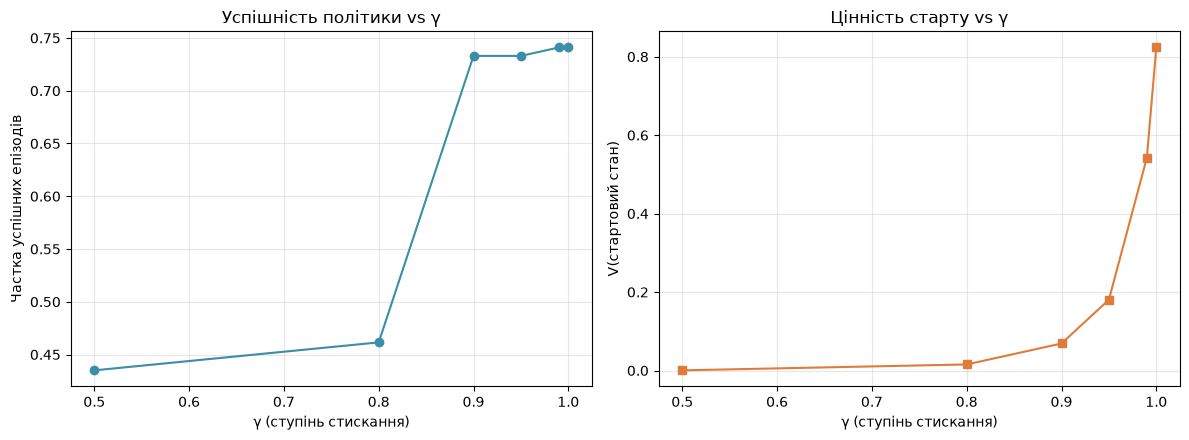

In [11]:
gs = [r[0] for r in results]
srs = [r[2] for r in results]
v0s = [r[1] for r in results]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(gs, srs, 'o-', color='#3b8ea5')
ax[0].set_xlabel('γ (ступінь стискання)'); ax[0].set_ylabel('Частка успішних епізодів')
ax[0].set_title('Успішність політики vs γ'); ax[0].grid(alpha=0.3)
ax[1].plot(gs, v0s, 's-', color='#e07b39')
ax[1].set_xlabel('γ (ступінь стискання)'); ax[1].set_ylabel('V(стартовий стан)')
ax[1].set_title('Цінність старту vs γ'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Порівняння політик для малого і великого $\gamma$

Policy Iteration збіглася на ітерації 5


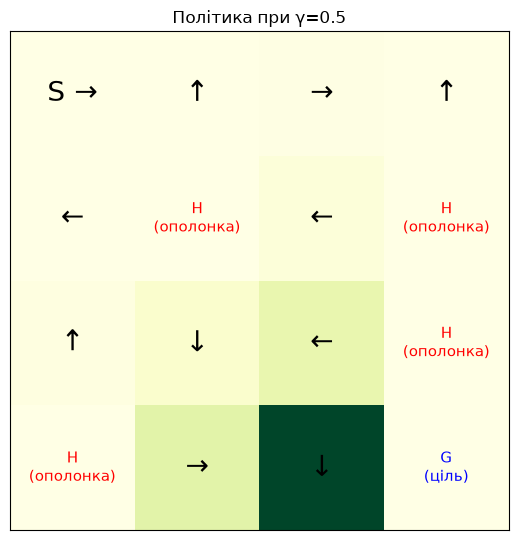

Policy Iteration збіглася на ітерації 7


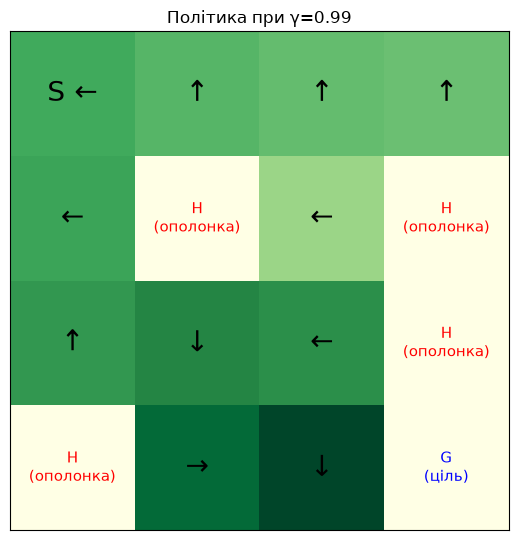

In [12]:
for g in [0.5, 0.99]:
    _, val = policy_iteration(env, gamma=g)
    plot_policy(policies[g], val, desc, f'Політика при γ={g}')

## Висновки

**Про метод.** Ітерація за політиками (Policy Iteration) знаходить оптимальну політику для FrozenLake **дуже швидко** — збіжність настає за 6–8 ітерацій. Алгоритм чергує *оцінку політики* (розв'язання рівнянь Беллмана для $V^\pi$) та *покращення політики* (жадібний вибір дії за Q-функцією), і зупиняється, коли політика перестає змінюватися.

**Про марковську природу задачі.** FrozenStake — це стохастичний MDP: слизький лід робить перехід випадковим (бажаний напрямок лише з $p=1/3$). Політика перетворює MDP на **ланцюг Маркова** над станами, а функція цінності $V(s)$ — це очікувана дисконтована винагорода цього ланцюга. Тому «оптимальна» політика часто веде агента **вздовж стін, подалі від ополонок**: вона мінімізує ризик випадково зісковзнути в `H`, а не шукає найкоротший шлях.

**Про ступінь стискання $\gamma$ (обчислювальні експерименти).**
- При **малому $\gamma$** (0.5) агент «короткозорий» — майже не цінує віддалену ціль, тож політика гірша, а цінність стартового стану близька до нуля.
- Зі **зростанням $\gamma$** до 0.9–1.0 агент починає враховувати довгострокову винагороду, політика стає осмисленою, а частка успішних епізодів зростає до **~0.74** — це практична межа для слизького озера $4\times4$.
- Цінність стартового стану $V(S)$ монотонно зростає з $\gamma$ (менше стискання майбутніх винагород — більша їх приведена вартість).

**Підсумок.** Policy Iteration ефективно розв'язує задачу навчання з підкріпленням на FrozenLake. Коефіцієнт стискання $\gamma$ — ключовий гіперпараметр: він визначає горизонт планування агента, і лише достатньо велике $\gamma$ дає політику, здатну надійно (наскільки дозволяє стохастика середовища) приводити агента до цілі.